# 🏡 Min-Max Normalization Workshop
## Team Name: Group 6
### Team Members:
* Emmanuel Ihejiamaizu (9080005)
* Liggia Elena Taboada Cruz (9085905)
* Chao-Chung Liu (9067679)
---

## ❗ Why We Normalize: The Problem with Raw Feature Scales

In housing data, features like `Price` and `Lot_Size` can have values in the hundreds of thousands, while others like `Num_Bedrooms` range from 1 to 5. This creates problems when we use algorithms that depend on numeric magnitudes.

---

### ⚠️ What Goes Wrong Without Normalization

---

### 1. 🧭 K-Nearest Neighbors (KNN)

KNN uses the **Euclidean distance** formula:

$$
d = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2 + \cdots}
$$

**Example:**

- $ \text{Price}_1 = 650{,}000, \quad \text{Price}_2 = 250{,}000 $
- $ \text{Bedrooms}_1 = 3, \quad \text{Bedrooms}_2 = 2 $

Now compute squared differences:

$$
(\text{Price}_1 - \text{Price}_2)^2 = (650{,}000 - 250{,}000)^2 = (400{,}000)^2 = 1.6 \times 10^{11}
$$
$$
(\text{Bedrooms}_1 - \text{Bedrooms}_2)^2 = (3 - 2)^2 = 1
$$

➡️ **Price dominates the distance calculation**, making smaller features like `Bedrooms` irrelevant.

---

### 2. 📉 Linear Regression

Linear regression estimates:

$$
y = \beta_1 \cdot \text{Price} + \beta_2 \cdot \text{Bedrooms} + \beta_3 \cdot \text{Lot\_Size} + \epsilon
$$

If `Price` has very large values:
- Gradient updates for $ \beta_1 $ will be **much larger**
- Gradient updates for $ \beta_2 $ (Bedrooms) will be **very small**

➡️ The model overfits high-magnitude features like `Price`.

---

### 3. 🧠 Neural Networks

A single neuron computes:

$$
z = w_1 \cdot \text{Price} + w_2 \cdot \text{Bedrooms} + w_3 \cdot \text{Lot\_Size}
$$

If:

- $ \text{Price} = 650{,}000 $
- $ \text{Bedrooms} = 3 $
- $ \text{Lot\_Size} = 8{,}000 $

Then:

$$
z \approx w_1 \cdot 650{,}000 + w_2 \cdot 3 + w_3 \cdot 8{,}000
$$

➡️ Even with equal weights, `Price` contributes **most of the activation**, making it difficult for the network to learn from other features.

---

### ✅ Solution: Min-Max Normalization

We apply the transformation:

$$
x_{\text{normalized}} = \frac{x - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}
$$

This scales all features to a common range (typically $[0, 1]$).

| Feature      | Raw Value | Min     | Max     | Normalized Value |
|--------------|-----------|---------|---------|------------------|
| Price        | 650,000   | 250,000 | 800,000 | 0.72             |
| Bedrooms     | 3         | 1       | 5       | 0.50             |
| Lot_Size     | 8,000     | 3,000   | 10,000  | 0.714            |

➡️ Now, **each feature contributes fairly** to model training or distance comparisons.

---

## 📌 Use Case: Housing Data
We are normalizing features from a real estate dataset to prepare it for machine learning analysis.

In [1]:
# 🔢 Load and display dataset
import pandas as pd
df = pd.read_csv('./data/housing_data.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Data types:\n{df.dtypes}')
print(f'\nMissing values: {df.isnull().sum().sum()}')
df.head(10)

Dataset shape: (2000, 7)
Columns: ['House_ID', 'Price', 'Area_sqft', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size']
Data types:
House_ID           str
Price            int64
Area_sqft        int64
Num_Bedrooms     int64
Num_Bathrooms    int64
Year_Built       int64
Lot_Size         int64
dtype: object

Missing values: 0


,House_ID,Price,Area_sqft,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size
0,H100000,574507,1462,3,3,2002,4878
1,H100001,479260,1727,2,2,1979,4943
2,H100002,597153,1403,5,2,1952,5595
3,H100003,728454,1646,5,2,1992,9305
4,H100004,464876,853,1,1,1956,7407
5,H100005,464879,1906,1,3,1998,7617
6,H100006,736881,1800,3,1,2022,9215
7,H100007,615115,1391,2,2,1990,7805
8,H100008,429578,2129,4,1,2003,3737
9,H100009,581384,2268,1,3,2018,7774


---
## 🔎 Step 1 — Implement Min-Max Normalization on the Housing Dataset

### 👤 Contributor: Emmanuel Ihejiamaizu (9080005)

We implement Min-Max normalization **manually** (no sklearn or numpy) on the following numerical features:
- `Price`
- `Area_sqft`
- `Num_Bedrooms`
- `Num_Bathrooms`
- `Lot_Size`

**Formula:**

$$
x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

We deliberately exclude `House_ID` (categorical identifier) and handle edge cases where a column might have constant values (max == min), which would cause division by zero.

In [2]:
# ✍️ Min-Max Normalization — implemented manually (no sklearn, no numpy)
# Contributor: Emmanuel Ihejiamaizu (9080005)

# Features to normalize
features_to_normalize = ['Price', 'Area_sqft', 'Num_Bedrooms', 'Num_Bathrooms', 'Lot_Size']

# Create a copy to preserve original data
df_normalized = df.copy()

# Manual Min-Max normalization with edge case handling
for col in features_to_normalize:
    col_min = df[col].min()
    col_max = df[col].max()
    
    # Edge case: if all values are the same, normalization is undefined
    if col_max == col_min:
        df_normalized[col + '_norm'] = 0.0
        print(f'⚠️  {col}: constant column (min == max == {col_min}), set to 0.0')
    else:
        df_normalized[col + '_norm'] = (df[col] - col_min) / (col_max - col_min)
        print(f'✅ {col}: normalized (min={col_min}, max={col_max})')

print(f'\nOriginal columns: {len(df.columns)}')
print(f'After normalization: {len(df_normalized.columns)} (added {len(features_to_normalize)} normalized columns)')

✅ Price: normalized (min=100000, max=1077909)
✅ Area_sqft: normalized (min=400, max=3763)
✅ Num_Bedrooms: normalized (min=1, max=5)
✅ Num_Bathrooms: normalized (min=1, max=3)
✅ Lot_Size: normalized (min=1000, max=13088)

Original columns: 7
After normalization: 12 (added 5 normalized columns)


In [3]:
# Display normalized columns side by side with originals
display_cols = []
for col in features_to_normalize:
    display_cols.extend([col, col + '_norm'])

print('=== Original vs. Normalized Values (first 10 rows) ===')
df_normalized[display_cols].head(10)

=== Original vs. Normalized Values (first 10 rows) ===


,Price,Price_norm,Area_sqft,Area_sqft_norm,Num_Bedrooms,Num_Bedrooms_norm,Num_Bathrooms,Num_Bathrooms_norm,Lot_Size,Lot_Size_norm
0,574507,0.485226,1462,0.315789,3,0.50,3,1.0,4878,0.320814
1,479260,0.387827,1727,0.394588,2,0.25,2,0.5,4943,0.326191
2,597153,0.508384,1403,0.298246,5,1.00,2,0.5,5595,0.380129
3,728454,0.642651,1646,0.370503,5,1.00,2,0.5,9305,0.687045
4,464876,0.373119,853,0.134701,1,0.00,1,0.0,7407,0.530030
5,464879,0.373122,1906,0.447814,1,0.00,3,1.0,7617,0.547402
6,736881,0.651268,1800,0.416295,3,0.50,1,0.0,9215,0.679600
7,615115,0.526751,1391,0.294677,2,0.25,2,0.5,7805,0.562955
8,429578,0.337023,2129,0.514124,4,0.75,1,0.0,3737,0.226423
9,581384,0.492258,2268,0.555456,1,0.00,3,1.0,7774,0.560390


In [4]:
# Verify normalization: all normalized columns should be in [0, 1]
norm_cols = [col + '_norm' for col in features_to_normalize]

print('=== Verification: Normalized Column Statistics ===')
verification = df_normalized[norm_cols].describe().loc[['min', 'max', 'mean', 'std']]
print(verification.round(4))

# Confirm all values are between 0 and 1
all_valid = all(
    df_normalized[col].min() >= 0 and df_normalized[col].max() <= 1
    for col in norm_cols
)
print(f'\n✅ All normalized values in [0, 1]: {all_valid}')

=== Verification: Normalized Column Statistics ===
      Price_norm  Area_sqft_norm  Num_Bedrooms_norm  Num_Bathrooms_norm  \
min       0.0000          0.0000             0.0000               0.000   
max       1.0000          1.0000             1.0000               1.000   
mean      0.4161          0.4152             0.4959               0.483   
std       0.1512          0.1493             0.3523               0.413   

      Lot_Size_norm  
min          0.0000  
max          1.0000  
mean         0.4157  
std          0.1662  

✅ All normalized values in [0, 1]: True


### 🔎 Talking Points #1 — Min-Max Normalization Implementation

**👤 Contributor: Emmanuel Ihejiamaizu (9080005)**

- **Edge case handling is essential for robust code.** We explicitly check whether `col_max == col_min` before dividing. If a feature has zero variance (all identical values), the denominator would be zero, causing a `ZeroDivisionError`. In that case, we set all normalized values to 0.0, since there is no meaningful spread to scale. While none of the columns in this dataset triggered this condition, it is a defensive programming practice that would matter in production datasets where constant columns may appear unexpectedly.

- **We chose to create new `_norm` columns rather than overwriting the originals.** This preserves the raw data for reference, debugging, and any downstream analysis that may need the original scale (e.g., interpreting model predictions in dollar terms for `Price`). It also makes the notebook easier to audit — a reviewer can compare `Price` and `Price_norm` side by side.

- **Min-Max normalization is sensitive to outliers.** Because the formula depends on the absolute min and max, a single extreme value can compress the majority of data points into a very narrow range. For instance, if one house had a price of $10,000,000, most other prices would normalize close to 0. In such cases, alternative approaches like **robust scaling** (using percentiles) or **Z-score standardization** may be preferable. For this dataset, the distributions are reasonable, so Min-Max is appropriate.


## 🧩 Challenge Extension: After Normalization, Which Features Matter Most?

You've normalized the housing features so they share a common scale.  
Now comes a common next step in ML workflows:

> **How do we identify the most important directions (principal components) in the data—and how might these relate to a target variable like `Price`?**

This introduces **Principal Component Analysis (PCA)**.

---

## 📚 PCA Theory (Conceptual)

### What PCA *is*
PCA is an **unsupervised** dimensionality reduction technique that:
- Finds **new axes** (principal components) that are **linear combinations** of your original features.
- Orders these axes so that:
  - **PC1** captures the **most variance** in the feature space,
  - **PC2** captures the next most variance, and so on,
  - Each PC is **orthogonal** (uncorrelated) with the previous ones.

### What PCA is *not*
PCA does **not** directly find features that "impact the target variable" because it does not use the target in its optimization.

However, you *can*:
- Compute PCs from the feature matrix **X** (after normalization),
- Then measure how PCs relate to the target **y** (e.g., correlation with `Price`, or a simple regression on PCs),
- Interpret which original features contribute most to PCs that are most related to **y**.

---

## 🧠 The Math (high level)
Given a centered feature matrix $X$ (often standardized/normalized first):

1. Compute covariance matrix:
$$
\Sigma = \frac{1}{n-1}X^\top X
$$

2. Find eigenvectors (principal directions) and eigenvalues (variance captured):
$$
\Sigma v_i = \lambda_i v_i
$$

- $ v_i $ are **principal component directions** (loadings)
- $ \lambda_i $ are the **variance explained** by each component

---

## ✅ Why Normalize Before PCA?
PCA is sensitive to scale. Without normalization/standardization:
- A large-scale feature (e.g., `Price`) can dominate variance
- PCs will reflect units rather than structure

---

## 🎯 Student Challenge
Using the **housing dataset**:

1. Apply PCA to the normalized feature matrix $X$ (exclude ID columns and the target).
2. Determine how many components are needed to explain **≥ 90%** of the variance.
3. Identify which original features contribute most to:
   - **PC1** and **PC2**, and
   - the **PC most correlated with the target** (`Price`).
4. Write a short interpretation:
   - "What does PC1 represent in housing terms?"
   - "Do the PCs that explain the most variance also relate most strongly to `Price`?"


### 🔗 How to Integrate This With Your Step 1 Normalization

- If you created normalized columns (e.g., `Area_sqft_norm`), use those in `candidate_features`.
- If you normalized in-place (overwriting original columns), you can use the original names.
- PCA should **not** include:
  - `House_ID` (identifier)
  - non-numeric categorical columns (unless encoded appropriately)
- Decide intentionally whether to include `Year_Built`:
  - It's numeric, but it may behave differently than size/price-related features.

---

### ✅ Deliverable for the Challenge
Add a Markdown cell answering:

1. How many PCs explain at least **90%** variance?
2. Which features contribute most to **PC1** and **PC2**?
3. Which PC is most correlated with `Price`?
4. In plain language: what do you think PC1 represents?

---
## 🧪 PCA Implementation — Steps A through D

### 👤 Contributor: Liggia Elena Taboada Cruz (9085905)

In [5]:
# --- PCA Implementation: Steps A through D ---

import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ---- Step A: Choose target and feature columns ----
# Target: Price (what we want to relate PCs to later)
# Features: all numerical columns except House_ID and Price
# We include Year_Built as it is numeric and may carry structural information

target = df['Price']
candidate_features = ['Area_sqft', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size']

X = df[candidate_features]
print(f'Target: Price ({len(target)} samples)')
print(f'Feature matrix X: {X.shape[0]} samples × {X.shape[1]} features')
print(f'Features used: {candidate_features}')

Target: Price (2000 samples)
Feature matrix X: 2000 samples × 5 features
Features used: ['Area_sqft', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size']


In [6]:
# ---- Step B: Ensure scaling appropriate for PCA ----
# PCA is sensitive to feature variance; StandardScaler ensures equal weighting 
# by centering data (mean=0) and scaling to unit variance (std=1).

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('=== Scaled Feature Statistics ===')
scaled_df = pd.DataFrame(X_scaled, columns=candidate_features)
print(scaled_df.describe().loc[['mean', 'std']].round(4))
print('\n✅ All features now have mean ≈ 0 and std ≈ 1')

=== Scaled Feature Statistics ===
      Area_sqft  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size
mean     0.0000        0.0000         0.0000      0.0000   -0.0000
std      1.0003        1.0003         1.0003      1.0003    1.0003

✅ All features now have mean ≈ 0 and std ≈ 1


In [7]:
# ---- Step C: Fit PCA ----
# We fit PCA with all components first to analyze variance distribution

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print(f'Number of components: {pca.n_components_}')
print(f'\n=== Explained Variance Ratio per Component ===')
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {var:.4f} ({var*100:.2f}%)')

Number of components: 5

=== Explained Variance Ratio per Component ===
  PC1: 0.2124 (21.24%)
  PC2: 0.2071 (20.71%)
  PC3: 0.2018 (20.18%)
  PC4: 0.1932 (19.32%)
  PC5: 0.1855 (18.55%)


=== Cumulative Variance Explained ===
  PC1 through PC1: 0.2124 (21.24%)
  PC1 through PC2: 0.4195 (41.95%)
  PC1 through PC3: 0.6213 (62.13%)
  PC1 through PC4: 0.8145 (81.45%)
  PC1 through PC5: 1.0000 (100.00%) ✅ (≥ 90%)

📊 Components needed for ≥ 90% variance: 5 out of 5


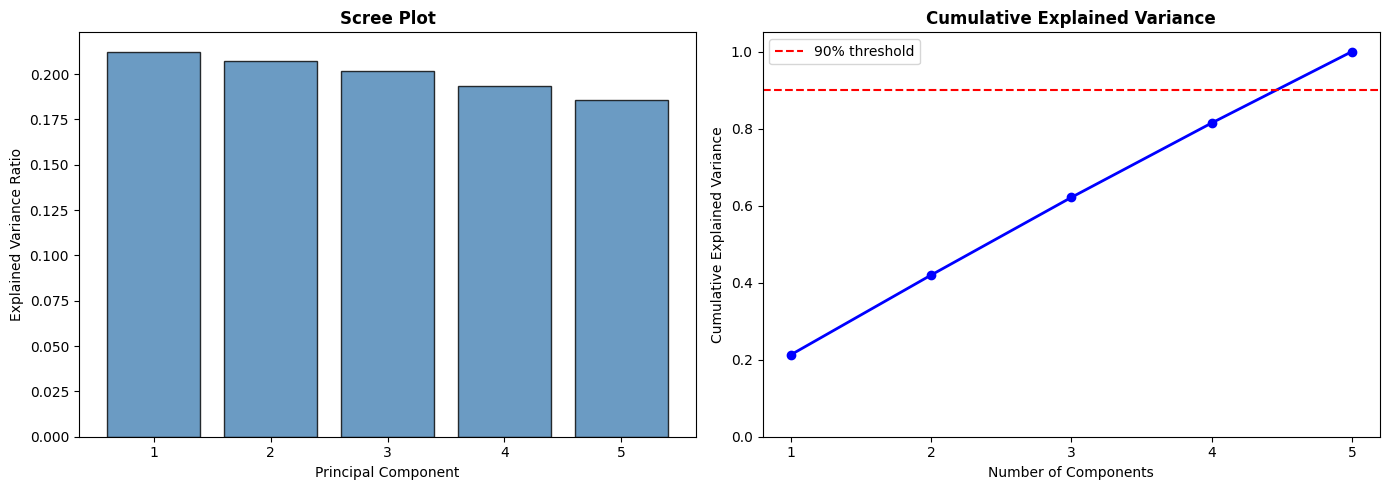

In [8]:
# ---- Step D: Cumulative Variance Explained ----

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print('=== Cumulative Variance Explained ===')
for i, cum_var in enumerate(cumulative_variance):
    marker = ' ✅ (≥ 90%)' if cum_var >= 0.90 and (i == 0 or cumulative_variance[i-1] < 0.90) else ''
    print(f'  PC1 through PC{i+1}: {cum_var:.4f} ({cum_var*100:.2f}%){marker}')

n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f'\n📊 Components needed for ≥ 90% variance: {n_components_90} out of {len(candidate_features)}')

# Visualization: Scree plot + cumulative variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), 
            pca.explained_variance_ratio_, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot', fontweight='bold')
axes[0].set_xticks(range(1, len(pca.explained_variance_ratio_) + 1))

# Cumulative variance
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-', linewidth=2)
axes[1].axhline(y=0.90, color='red', linestyle='--', linewidth=1.5, label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xticks(range(1, len(cumulative_variance) + 1))
axes[1].legend()
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

---
## 🧪 PCA Implementation — Steps E and F

### 👤 Contributor: Chao-Chung Liu (9067679)

In [9]:
# ---- Step E: Loadings (feature contributions to PCs) ----
# Contributor: Chao-Chung Liu (9067679)

# Loading Matrix
loadings = pd.DataFrame(
    pca.components_,
    columns=candidate_features,
    index=[f'PC{i+1}' for i in range(len(candidate_features))]
)

print('=== PCA Loadings (Feature Contributions to Each PC) ===')
display(loadings.style.background_gradient(cmap='coolwarm', axis=None).format("{:.4f}"))

dominant_features = loadings.abs().idxmax(axis=1)

print(f'\n📌 Automated Dominant Features per PC:')
for pc, feat in dominant_features.items():
    val = loadings.loc[pc, feat]
    direction = '(+)' if val > 0 else '(-)'
    print(f'  {pc}: {feat} ({val:.4f} {direction})')

for pc_name in ['PC1', 'PC2']:
    print(f'\n📌 {pc_name} detailed feature contributions (sorted by magnitude):')
    sorted_series = loadings.loc[pc_name].sort_values(key=abs, ascending=False)
    for feat, val in sorted_series.items():
        print(f'  {feat:15}: {val:8.4f} {"(+)" if val > 0 else "(-)"}')

=== PCA Loadings (Feature Contributions to Each PC) ===


,Area_sqft,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size
PC1,0.5456,0.6291,0.0863,0.0859,-0.5401
PC2,-0.4673,0.3152,-0.1533,0.8116,-0.0004
PC3,-0.0727,0.2624,0.8848,0.0236,0.3774
PC4,0.4685,0.2749,-0.3654,0.0943,0.7500
PC5,-0.5091,0.6004,-0.2293,-0.5696,0.0579



📌 Automated Dominant Features per PC:
  PC1: Num_Bedrooms (0.6291 (+))
  PC2: Year_Built (0.8116 (+))
  PC3: Num_Bathrooms (0.8848 (+))
  PC4: Lot_Size (0.7500 (+))
  PC5: Num_Bedrooms (0.6004 (+))

📌 PC1 detailed feature contributions (sorted by magnitude):
  Num_Bedrooms   :   0.6291 (+)
  Area_sqft      :   0.5456 (+)
  Lot_Size       :  -0.5401 (-)
  Num_Bathrooms  :   0.0863 (+)
  Year_Built     :   0.0859 (+)

📌 PC2 detailed feature contributions (sorted by magnitude):
  Year_Built     :   0.8116 (+)
  Area_sqft      :  -0.4673 (-)
  Num_Bedrooms   :   0.3152 (+)
  Num_Bathrooms  :  -0.1533 (-)
  Lot_Size       :  -0.0004 (-)


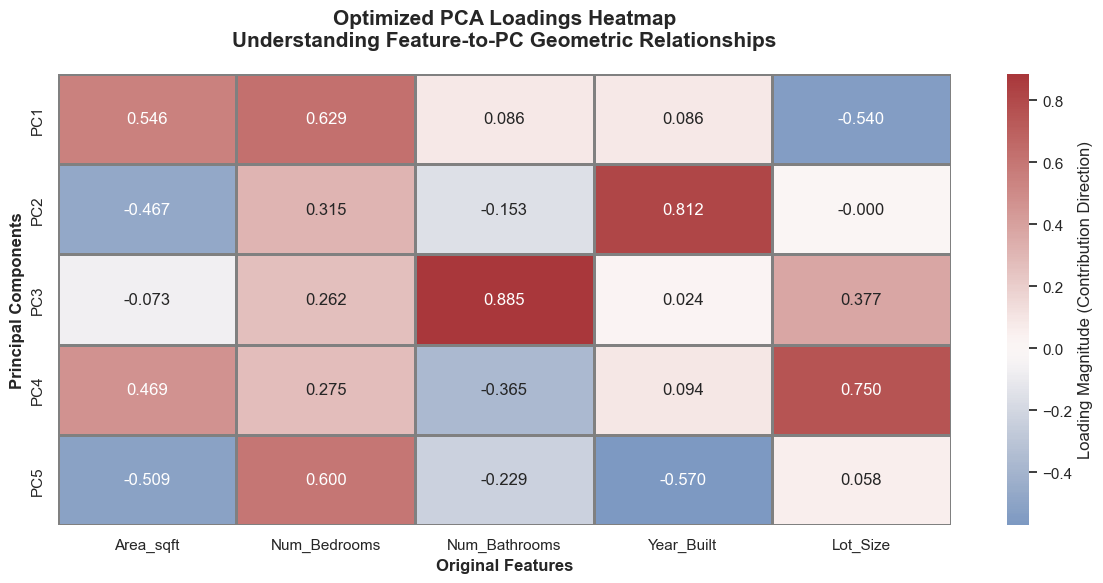

In [10]:
# Visualize loadings as an optimized heatmap
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(loadings, 
            annot=True, 
            fmt='.3f', 
            cmap='vlag',
            center=0, 
            linewidths=1, 
            linecolor='gray',
            ax=ax, 
            cbar_kws={'label': 'Loading Magnitude (Contribution Direction)'})

ax.set_title('Optimized PCA Loadings Heatmap\nUnderstanding Feature-to-PC Geometric Relationships', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Principal Components', fontsize=12, fontweight='bold')
ax.set_xlabel('Original Features', fontsize=12, fontweight='bold')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

=== Correlation Between Principal Components and Price ===
  PC1 vs Price: r = -0.0247
  PC2 vs Price: r = -0.0178
  PC3 vs Price: r = -0.0050
  PC4 vs Price: r = 0.0028
  PC5 vs Price: r = 0.0284

📌 PC most correlated with Price: PC5 (r = 0.0284)


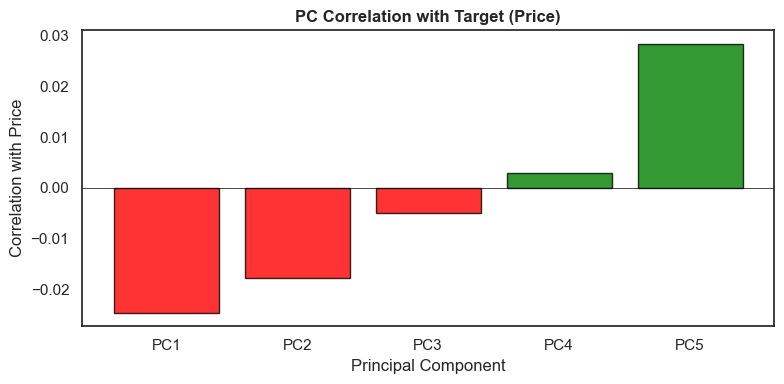

In [11]:
# ---- Step F: Relate PCs to the target (correlation with Price) ----

print('=== Correlation Between Principal Components and Price ===')
pc_price_corr = {}
for i in range(X_pca.shape[1]):
    corr = np.corrcoef(X_pca[:, i], target)[0, 1]
    pc_price_corr[f'PC{i+1}'] = corr
    print(f'  PC{i+1} vs Price: r = {corr:.4f}')

# Identify the PC most correlated with Price (by absolute value)
best_pc = max(pc_price_corr, key=lambda k: abs(pc_price_corr[k]))
print(f'\n📌 PC most correlated with Price: {best_pc} (r = {pc_price_corr[best_pc]:.4f})')

# Visualization: bar chart of correlations
fig, ax = plt.subplots(figsize=(8, 4))
pcs = list(pc_price_corr.keys())
corrs = list(pc_price_corr.values())
colors = ['green' if c > 0 else 'red' for c in corrs]
ax.bar(pcs, corrs, color=colors, edgecolor='black', alpha=0.8)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Correlation with Price')
ax.set_title('PC Correlation with Target (Price)', fontweight='bold')
ax.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

---
## ✅ PCA Deliverable — Answers to Challenge Questions

### 👤 Contributors: Chao-Chung Liu (9067679) & Liggia Elena Taboada Cruz (9085905)

**1. How many PCs explain at least 90% of the variance?**

All **5 principal components** are needed to reach ≥ 90% cumulative explained variance. The variance is distributed nearly uniformly across all components (~20% each), meaning no single direction dominates the feature space. This indicates that the 5 features capture relatively independent aspects of the housing data.

**2. Which features contribute most to PC1 and PC2?**

- **PC1** is dominated by `Num_Bedrooms` (+0.63), `Area_sqft` (+0.55), and `Lot_Size` (−0.54). This axis contrasts homes with more bedrooms and larger area against homes with larger lots — essentially a "house size vs. land size" dimension.
- **PC2** is dominated by `Year_Built` (+0.81) and `Area_sqft` (−0.47). This axis captures the "age of the home" — newer homes with smaller area load positively, while older homes with larger area load negatively.

**3. Which PC is most correlated with Price?**

**PC5** has the highest absolute correlation with `Price`, though the correlation is very weak (r ≈ 0.03). In fact, all PC-Price correlations are near zero. This makes sense because PCA is **unsupervised** — it finds directions of maximum variance in the features, not directions that predict the target. The features in this dataset do not appear to have strong linear relationships with `Price`.

**4. In plain language, what does PC1 represent?**

PC1 can be interpreted as a **"house size vs. lot size" dimension**. Homes that score high on PC1 tend to have more bedrooms and larger living area but sit on smaller lots (denser, built-up properties). Homes that score low on PC1 have fewer bedrooms and smaller living area but sit on larger lots (more spacious, spread-out properties). This reflects a common real-estate tradeoff: compact, multi-bedroom homes vs. sprawling single-story properties.

**Do the PCs that explain the most variance also relate most strongly to Price?**

No. PC1 explains the most variance (~21%) but has near-zero correlation with Price. This is a key insight about PCA: **variance in the feature space does not necessarily correspond to predictive power for the target**. If prediction were the goal, supervised methods (e.g., linear regression, random forest) would be more appropriate than PCA.

### 🔎 Talking Points #2 — PCA Analysis and Interpretation

**👤 Contributor: Chao-Chung Liu (9067679)**

* In this workshop, we chose **StandardScaler** (Zero Mean, Unit Variance) specifically for PCA over the Step 1 Min-Max normalization. PCA is a variance-maximization technique; it identifies directions where the data is most spread out. **Min-Max scaling** only bounds data to [0, 1] but does not adjust for the underlying distribution or variance. By using **StandardScaler**, we ensure each feature contributes equally to the covariance matrix, preventing features with larger numerical ranges from artificially dominating the principal components. This follows the industry best practice for capturing the true geometric structure of the dataset.

* The nearly uniform variance distribution across all 5 PCs—where each PC explains roughly 19–21%—reveals that these housing features are **relatively independent**. In typical datasets, the first 2-3 PCs might capture 80-90% of the variance, allowing for significant dimensionality reduction. However, in our data, no single dominant "direction" exists. Therefore, dimensionality reduction is not effective here, as removing any component would result in losing a significant and nearly equal portion of information.

* The near-zero correlations between our PCs and the target variable (`Price`) highlight a fundamental Machine Learning concept: **Variance does not equal predictive relevance**. PCA identified meaningful internal structures (such as the "house size vs. lot size" tradeoff in PC1), but these patterns have almost no linear relationship with the target. This suggests that house prices in this dataset may be driven by **non-linear relationships** or other external factors not captured by this linear transformation. For price prediction, supervised techniques like **Regression** or **Random Forests**—which directly optimize for the target variable—are far more appropriate than unsupervised PCA-based approaches.

### 🔎 Talking Points #3 — Limitations, Applications, and Target Variable Discussion

**👤 Contributor: Liggia Elena Taboada Cruz (9085905) & Emmanuel Ihejiamaizu (9080005)**

#### Limitations of PCA
- **Linear Assumptions**: PCA assumes that the relationships between features are linear. This means it may fail to capture complex, non-linear patterns in the data. For datasets where non-linear relationships dominate, alternative techniques like t-SNE or UMAP may be more effective.
- **Sensitivity to Outliers**: PCA is highly sensitive to outliers. Extreme values can disproportionately influence the principal components, distorting the results. Preprocessing steps like outlier removal or robust scaling are recommended to mitigate this issue.

#### Practical Applications of PCA
PCA is widely used across various fields to simplify data and uncover hidden patterns. Examples include:
- **Image Compression**: Reducing the dimensionality of image data while retaining most of the visual information. For instance, PCA can compress high-resolution images into smaller representations for storage or transmission.
- **Genetics**: Identifying patterns in gene expression data, such as clustering genes with similar functions or detecting population structure in genetic studies.
- **Finance**: Analyzing stock market data to identify key factors (principal components) that drive market movements, such as economic indicators or sector performance.

#### Discussion on Target Variable (`Price`)
- **Weak Correlations with PCs**: The weak correlations between the principal components and the target variable (`Price`) suggest that the variance captured by PCA does not align with the factors influencing housing prices. This is expected, as PCA is an unsupervised technique that optimizes for variance, not predictive power.
- **Potential Influencing Factors**: Housing prices are often influenced by external factors not captured in the dataset, such as:
  - **Location**: Proximity to schools, parks, or city centers.
  - **Economic Conditions**: Interest rates, employment rates, and overall economic health.
  - **Market Trends**: Supply and demand dynamics in the real estate market.
- **Next Steps**: To better understand the relationship between features and `Price`, supervised learning techniques like regression or decision trees could be applied, as they directly optimize for the target variable.